##**Image-Sharpening ConvNet**

We are going to work with high-res images of a bunch of manga comicbook covers. Word of warning: high-res images means tons of pixels, which means tons of data in memory and big tensor operations.

# Import Dataset

Mount Google Drive.

In [1]:
import pandas as pd
from google.colab import files
import io

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the image dataset and manipulate it.

Found 107 image files.
Processed 107 images into image_list.
The shape of each image is (584, 416, 3).


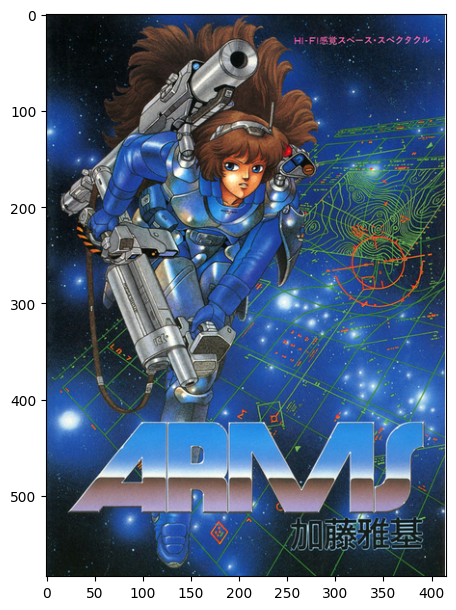

In [2]:
import numpy as np
import glob
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

image_list = []
image_files = glob.glob("/content/drive/My Drive/Teaching/Courses/BA 865/BA865-2026/6_Apr 7/manga_low/*")

print(f"Found {len(image_files)} image files.")

for file in image_files:
    im=Image.open(file)

    # I am stripping off the last row. Why?
    img_array = np.array(im)[:-1,:,:]

    # I am adding two cols of white pixels too. Why?
    white = np.ones(shape=(584,2,3))*255
    img_array = np.hstack([img_array,white])
    img_array = np.divide(img_array,255)
    image_list.append(img_array)

print(f"Processed {len(image_list)} images into image_list.")

if not image_list:
    print("Error: No images were loaded. Please ensure the path is correct and contains images.")
else:
    dpi = 80

    height, width, depth = image_list[0].shape
    figsize = width / float(dpi), height / float(dpi)

    print(f'The shape of each image is {image_list[0].shape}.')

    plt.figure(figsize=figsize)
    plt.imshow(image_list[0])
    plt.show()

#*Optional: Dataset Augmentation.*

With image data, it's pretty straight forward for us to synthesize new training examples by copying and then randomly manipulating the images we've already got!

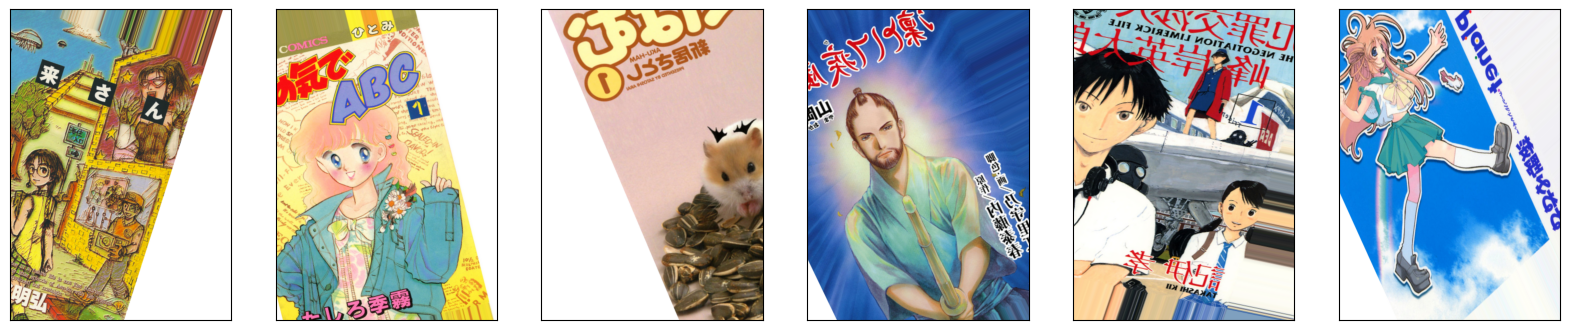

We now have a total of 304 images.


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

datagen = ImageDataGenerator(
    rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest')

# First, 'train' the image data generator on our sample.
datagen.fit(image_list)

# Now we create the iterator... we can keep pulling new randomly transformed pictures out of this forever.
image_batches = datagen.flow(np.stack(image_list,axis=0), batch_size=30)

n = 5
plt.figure(figsize= (20,10))

q = 0
for i,batch in enumerate(image_batches):
    for j, image in enumerate(batch):
        if j == 1:
            # Only plot the first 6 photos.
            if i <= 5:
                ax = plt.subplot(1, 6, i+1)
                plt.imshow(tf.keras.utils.array_to_img(image))
                ax.get_xaxis().set_visible(False)
                ax.get_yaxis().set_visible(False)

        # The iterator outputs image data with pixel values between 0-1; we are using values between 0-255 elsewhere.
        # We need to make the pixel values align.
        image_list.append(image)

    # Telling the script to stop asking for new images after several batches.
    if q > 5:
      break

    q += 1

plt.show()

print(f'We now have a total of {len(image_list)} images.')

Lastly, let's make our X's now; the pixellated versions of the high resolution images.

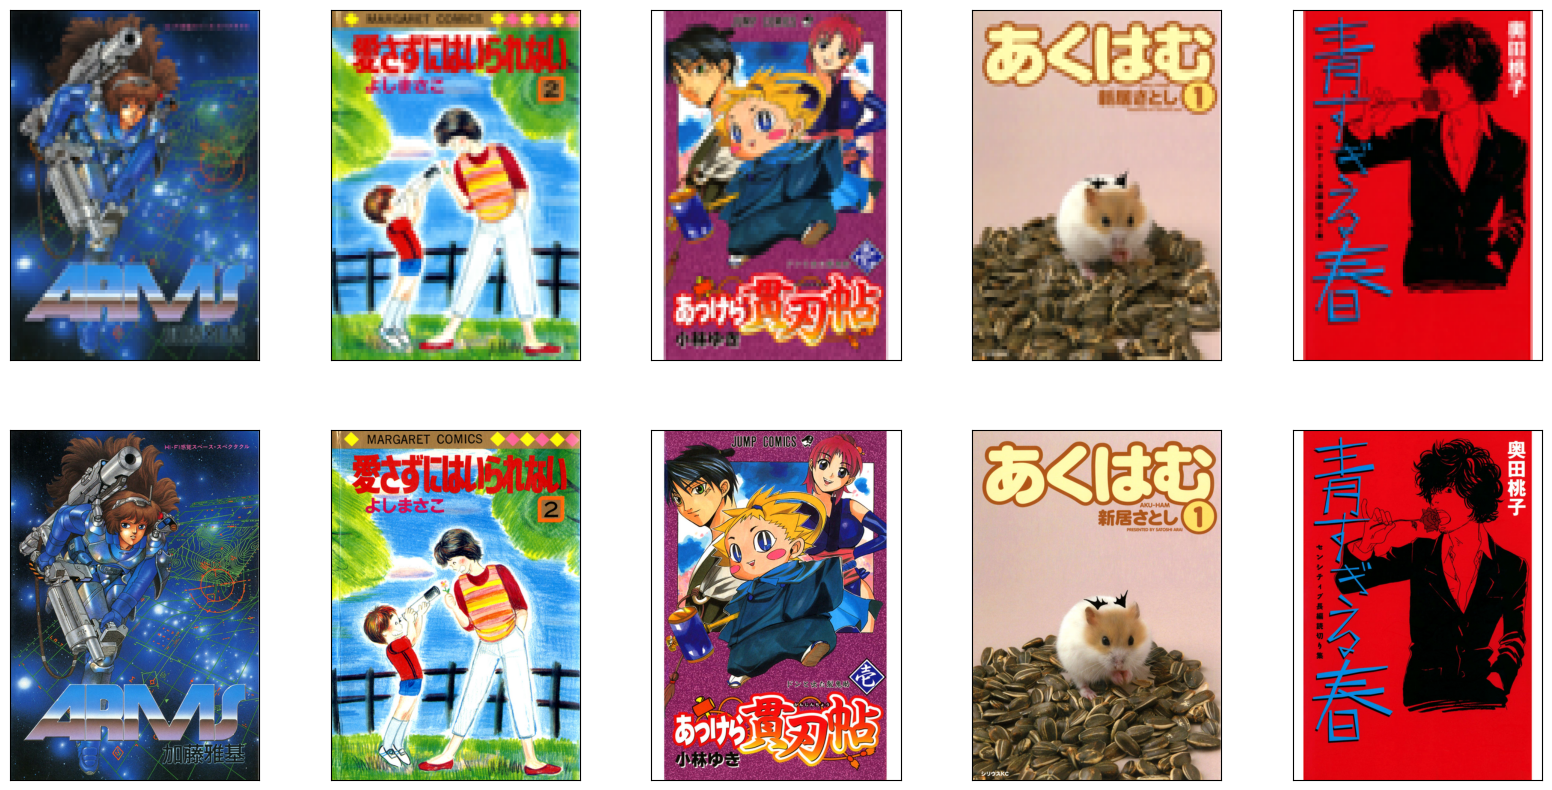

In [4]:
import tensorflow as tf
import numpy as np

pixelated_list = []

# This part determines how difficult the problem is.
# If we downsample too much, there's not enough signal left in the data to recover the original.
# Try this with downsampling to 100x100 or even lower. The model won't be able to solve the problem.
for image in image_list:
    image = Image.fromarray(np.multiply(image, 255).astype('uint8'))
    # Next, make the pixelated version of the original image.
    image_tiny = image.resize((100, 100))  # resize it to a tiny size
    pixelated = image_tiny.resize(image.size, Image.NEAREST)  # scale it back up
    # Store the pixelated photo, normalized to [0, 1] to match image_list.
    pixelated = tf.keras.utils.img_to_array(pixelated) / 255.0
    pixelated_list.append(pixelated)

# We will put these into NumPy arrays for use in our NN later.
pixelated_array = np.stack(pixelated_list, axis=0)
image_array = np.stack(image_list, axis=0)

# Let's plot the first 5 pairs of training images and their labels (in RGB).
n = 5

plt.figure(figsize=(20, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(pixelated_list[i])  # Already [0,1], matplotlib handles this fine
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(image_list[i])  # Already [0,1]
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

# Create Our Neural Network

Now, we just need to create a model that takes the pixelated image as input, and tries to predict the original.

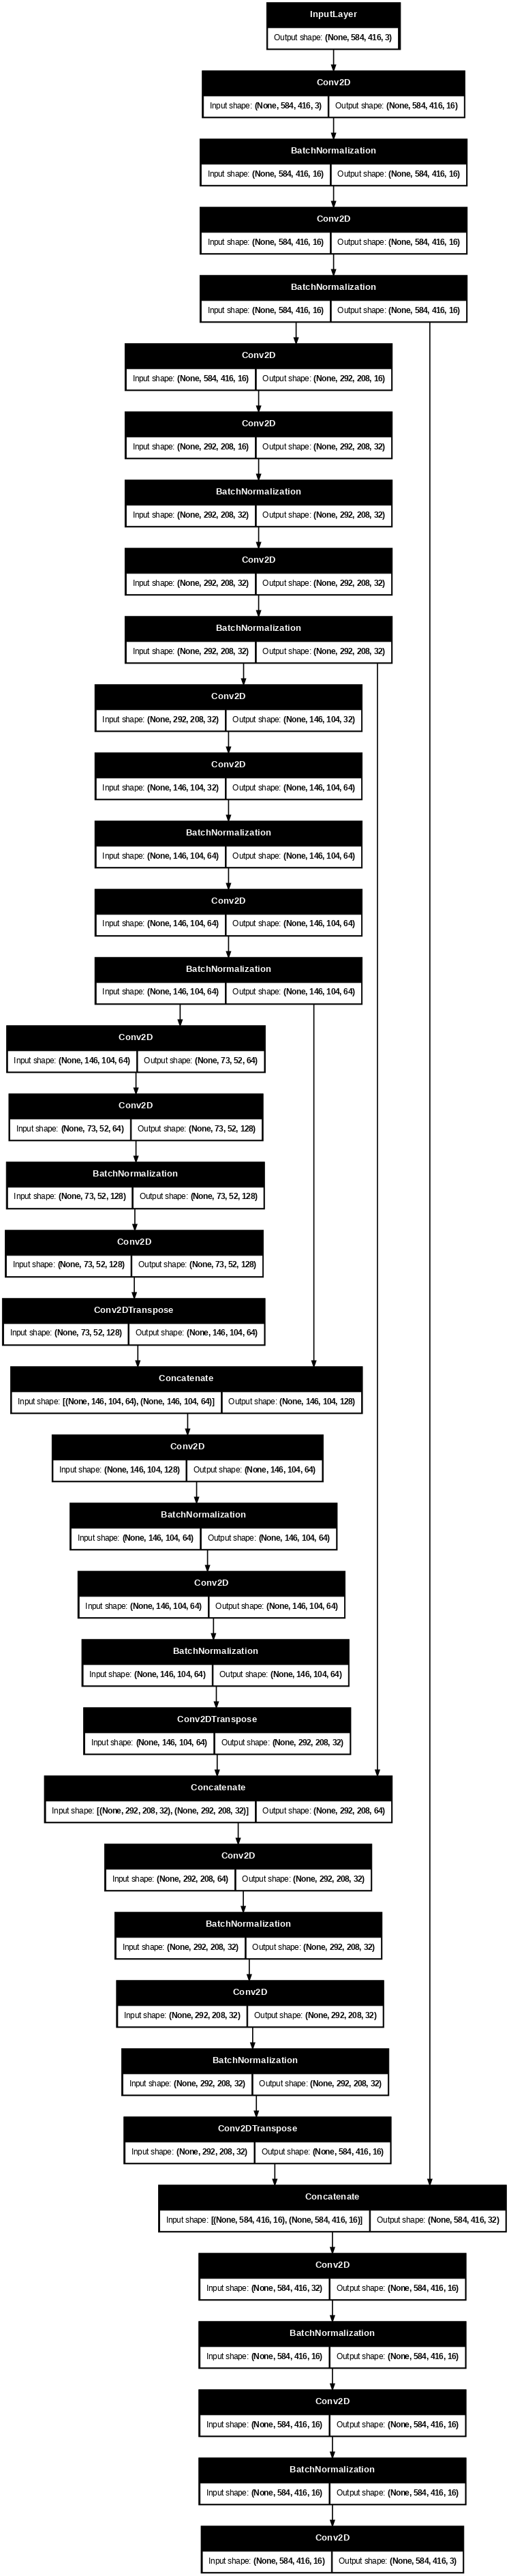

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import math

# PSNR is 'peak signal-to-noise ratio', a loss metric that is specific to assessing image quality.
# This is a custom loss function we are defining for use here.
# Note: max_pixel=1.0 because our data is normalized to [0, 1].
# Higher PSNR is desirable, so we multiply by -1 because optimizers minimize loss by default.
def psnrLoss(y_true, y_pred, max_pixel=1.0):
    psnr = tf.image.psnr(y_true, y_pred, max_val=max_pixel)
    return -1 * psnr

# Batch size is unstated for now, but a given observation has height and width of images, and 3 color channels.
inputs = keras.Input(shape=(height, width, 3))

# Encoder portion

# Block 1
x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(x)
skip1 = layers.BatchNormalization()(x)  # Save for skip connection
x = layers.Conv2D(16, (3,3), strides=2, activation="relu", padding="same")(skip1)  # Learned downsampling

# Block 2
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
skip2 = layers.BatchNormalization()(x)  # Save for skip connection
x = layers.Conv2D(32, (3,3), strides=2, activation="relu", padding="same")(skip2)  # Learned downsampling

# Block 3
x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
skip3 = layers.BatchNormalization()(x)  # Save for skip connection
x = layers.Conv2D(64, (3,3), strides=2, activation="relu", padding="same")(skip3)  # Learned downsampling

# Bottleneck
x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)
encoding = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)

# Decoder portion

# Block 1 — upsample and concatenate skip3
x = layers.Conv2DTranspose(64, (3,3), strides=2, activation="relu", padding="same")(encoding)
x = layers.Concatenate()([x, skip3])  # Skip connection from encoder block 3
x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)  # Added second conv
x = layers.BatchNormalization()(x)

# Block 2 — upsample and concatenate skip2
x = layers.Conv2DTranspose(32, (3,3), strides=2, activation="relu", padding="same")(x)
x = layers.Concatenate()([x, skip2])  # Skip connection from encoder block 2
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)  # Added second conv
x = layers.BatchNormalization()(x)

# Block 3 — upsample and concatenate skip1
x = layers.Conv2DTranspose(16, (3,3), strides=2, activation="relu", padding="same")(x)
x = layers.Concatenate()([x, skip1])  # Skip connection from encoder block 1
x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(x)  # Added second conv
x = layers.BatchNormalization()(x)

outputs = layers.Conv2D(3, (3,3), activation="sigmoid", padding="same")(x)

model = keras.Model(inputs, outputs)

# Compile the model with our custom loss function.
# Using a slightly lower learning rate for more stable training.
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss=psnrLoss, metrics=['mse'])

keras.utils.plot_model(model, show_shapes=True, dpi=60)

We can get a summary of the trainable parameters in our network...

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 584, 416,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 584, 416,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 584, 416,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 584, 416,  │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 584, 416,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 292, 208,  │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 292, 208,  │      4,640 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 292, 208,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 292, 208,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 292, 208,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 146, 104,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 146, 104,  │     18,496 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 146, 104,  │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 146, 104,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 146, 104,  │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 73, 52,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 73, 52,    │     73,856 │ conv2d_8[0][0]  

 Total params: 587,011 (2.24 MB)

 Trainable params: 585,859 (2.23 MB)

 Non-trainable params: 1,152 (4.50 KB)

Okay, let's try fitting this model...

In [7]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "/content/drive/My Drive/Teaching/Courses/BA 865/BA865-2026/6_Apr 7/superResolution.keras",
        save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
    )
]

history = model.fit(pixelated_array,image_array,batch_size=16, epochs=100, validation_split=0.2,callbacks=callbacks)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - loss: -7.7763 - mse: 0.1728 - val_loss: -8.9188 - val_mse: 0.1333 - learning_rate: 1.0000e-04
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 339ms/step - loss: -10.0068 - mse: 0.1026 - val_loss: -9.2543 - val_mse: 0.1230 - learning_rate: 1.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - loss: -11.3354 - mse: 0.0760 - val_loss: -9.6787 - val_mse: 0.1113 - learning_rate: 1.0000e-04
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 339ms/step - loss: -12.5634 - mse: 0.0571 - val_loss: -10.0175 - val_mse: 0.1029 - learning_rate: 1.0000e-04
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 339ms/step - loss: -13.4455 - mse: 0.0467 - val_loss: -10.3140 - val_mse: 0.0961 - learning_rate: 1.0000e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 340ms/step - loss: -14.2681 - mse: 0.0387 - val_loss: -10.6807 - val_mse: 0.0884 - learning_rate: 1.0000e-04
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 342ms/step - loss: -14.9299 - mse: 0.0334 - val_loss: -11.

And, let's plot the loss over epochs...

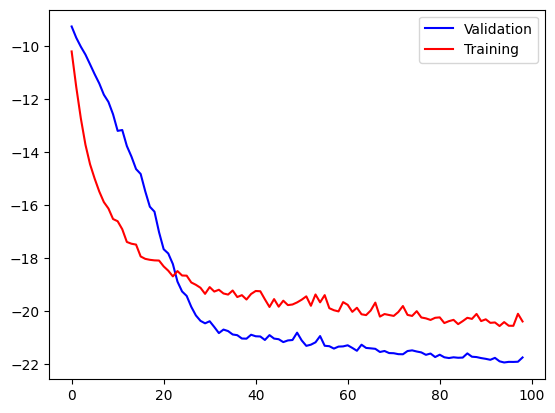

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_loss'][1:],c="b")
plt.plot(history.history['loss'][1:],c="r")
plt.legend(['Validation','Training'])
plt.show()

Let's spit out some of the predictions from this model to see how well it works...

In [9]:
custom_stuff = {'psnrLoss': psnrLoss}

model = keras.models.load_model("/content/drive/My Drive/Teaching/Courses/BA 865/BA865-2026/6_Apr 7/superResolution.keras",
                                custom_objects=custom_stuff)

sharpened_array = model.predict(pixelated_array[:15])

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


Our sharpener works, though it has some trouble with white pixels (it fills in some black pixels). It may need more white examples to figure those out well.

In [10]:
n = 5

plt.figure(figsize=(20, 15))

for i in range(n):
    # Row 1: Pixelated input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(pixelated_array[i])  # [0,1] range, displays correctly
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel("Pixelated", fontsize=14)
    # Row 2: Model output (sharpened)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(np.clip(sharpened_array[i], 0, 1))  # Clip to valid range
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel("Sharpened", fontsize=14)
    # Row 3: Original ground truth
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(image_array[i])  # [0,1] range
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel("Original", fontsize=14)

plt.tight_layout()

plt.show()

Output hidden; open in https://colab.research.google.com to view.